# Импорты библиотек

Код ниже определяет метод, при вызове которого скачивается датасет California Housing Prices, это классический датасет на котором принято проводить первые шаги в Разведывательном анализе данных (Exploratory Data Analysis). 

In [ ]:
import os
import tarfile
import urllib

DOWNLOAD_ROOT = "https://raw.githubusercontent.com/ageron/handson-ml2/master/"
HOUSING_PATH = os.path.join("datasets", "housing")
HOUSING_URL = DOWNLOAD_ROOT + "datasets/housing/housing.tgz"


def fetch_housing_data(housing_url=HOUSING_URL, housing_path=HOUSING_PATH):
    os.makedirs(housing_path, exist_ok=True)
    tgz_path = os.path.join(housing_path, "housing.tgz")
    urllib.request.urlretrieve(housing_url, tgz_path)
    housing_tgz = tarfile.open(tgz_path)
    housing_tgz.extractall(path=housing_path)
    housing_tgz.close()


# команда запуска метода, создает в директории с данным ноутбуком папку,
# в которую загружается и разархивируется датасет
fetch_housing_data()

C:\Users\sunsh\AppData\Local\Temp\ipykernel_15688\1010757020.py:14: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  housing_tgz.extractall(path=housing_path)


Код ниже запускает чтение файла из созданной выше папки.

In [ ]:
import pandas as pd


def load_housing_data(housing_path=HOUSING_PATH):
    csv_path = os.path.join(housing_path, "housing.csv")
    return pd.read_csv(csv_path)


# команда запускает загрузку датасета в переменную housing и выводит первые 5 строк
housing = load_housing_data()
housing.head()

df = housing

# Задание №1. Загрузка и первичный осмотр.
Загрузите датасет. Выведите последние 5 строк таблицы. Используя метод .info(), определите, какой тип данных у каждого признака и сколько памяти занимает датасет и сколько в нем строк.

In [19]:
df.tail()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND
20639,-121.24,39.37,16.0,2785.0,616.0,1387.0,530.0,2.3886,89400.0,INLAND


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


# Задание №2. Статистический анализ.
Используйте метод .describe(). Ответьте на вопросы:
- Каков средний медианный доход (median_income) в массиве?
- Каков максимальный возраст жилья (housing_median_age)?
- На что указывает разница между средним значением (mean) и медианой (50%) для признака total_rooms?

In [ ]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


Напишите ответы на вопросы здесь в виде пунктов:
- 1. median_income.mean() = 3.870671
- 2. house_median_age.max() = 52.000000
- 3. указывает на большой разброс (от 2 комнат до 39320). Mean = ср. значение, 50% - медианное значение 

# Задание №3. Анализ пропусков.
Найдите столбец, в котором есть пропущенные значения (NaN). Определите количество пропусков и их долю от общего числа записей. Заполните пропуски медианным значением по этому столбцу (используйте fillna).

In [ ]:
# нахожу столбцы с NaN (1=total_bedrooms) и общее кол-во пропусков (207)
n_missing = df.isnull().sum()
n_missing

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [ ]:
# определяю долю пропусков от общего числа записей (1%)
total_rows = len(df)
isnull_percentage = (n_missing / total_rows) * 100
isnull_percentage

longitude             0.000000
latitude              0.000000
housing_median_age    0.000000
total_rooms           0.000000
total_bedrooms        1.002907
population            0.000000
households            0.000000
median_income         0.000000
median_house_value    0.000000
ocean_proximity       0.000000
dtype: float64

In [ ]:
# заполняю пропуски медианным значением по этому столбцу, используя fillna
median_rooms = df["total_bedrooms"].median()
df["total_bedrooms"].fillna(median_rooms)
df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

# Задание №4. Категориальные признаки.
Изучите столбец ocean_proximity. Выведите список уникальных значений и количество записей для каждого значения(используйте .value_counts()). Также воспользуйтесь командой .reset_index() для более удобного представления результата.

In [ ]:
# список уникальных значений и кол-во записей для каждого значения
proximity_counts = df["ocean_proximity"].value_counts()
proximity_index = proximity_counts.reset_index()

proximity_index

,ocean_proximity,count
0,<1H OCEAN,9136
1,INLAND,6551
2,NEAR OCEAN,2658
3,NEAR BAY,2290
4,ISLAND,5


# Задание №5. Постройте гистограмму распределения целевой переменной median_house_value.
Заметили ли вы странность в правой части графика (на значении 500,000+)? Как вы можете это объяснить?

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

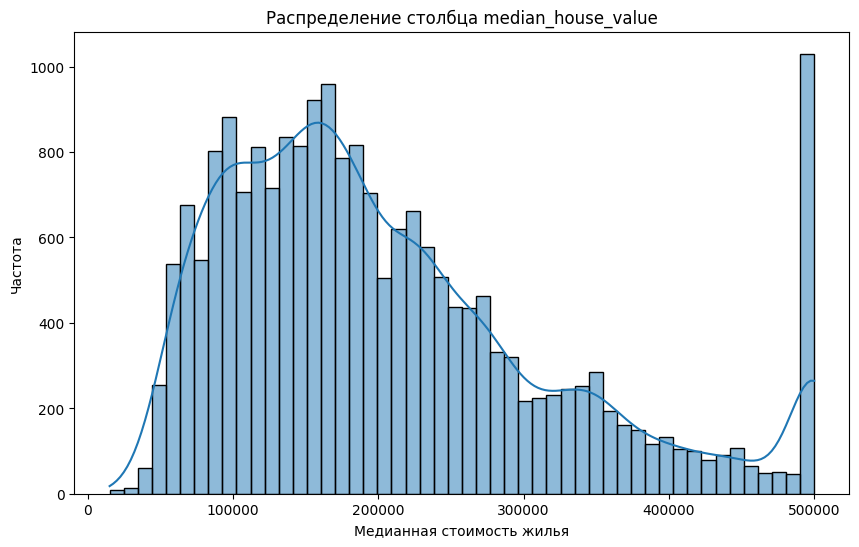

In [ ]:
# строю гистограмму распределения целевой переменной median_house_value
plt.figure(figsize=(10, 6))
sns.histplot(df["median_house_value"], bins=50, kde=True)
plt.title("Распределение столбца median_house_value")
plt.xlabel("Медианная стоимость жилья")
plt.ylabel("Частота")
plt.show()

Напишите ответы на вопросы здесь в виде пунктов:
1. Заметили ли вы странность в правой части графика (на значении 500,000+)? Да, в правой части графика, вместо плавного спада, наблюдается аномально высокий столбец, сконцентрированный именно на отметке 500000+.
2. Как вы можете это объяснить? Возможно, данные были искусственно ограничены этим значением - например, чтобы не раскрывать реальную стоимость дорогих квартир. В итоге множество объектов с реальной стоимостью выше порога "схлопнулись" в одну точку.

# Задание №6. Географическая карта
Поскольку у нас есть широта (latitude) и долгота (longitude), постройте scatterplot.
- По оси X — долгота, по оси Y — широта. 
- Добавьте параметр alpha=0.1, чтобы увидеть плотность застройки.
- Раскрасьте точки цветом в зависимости от стоимости жилья (c='median_house_value').

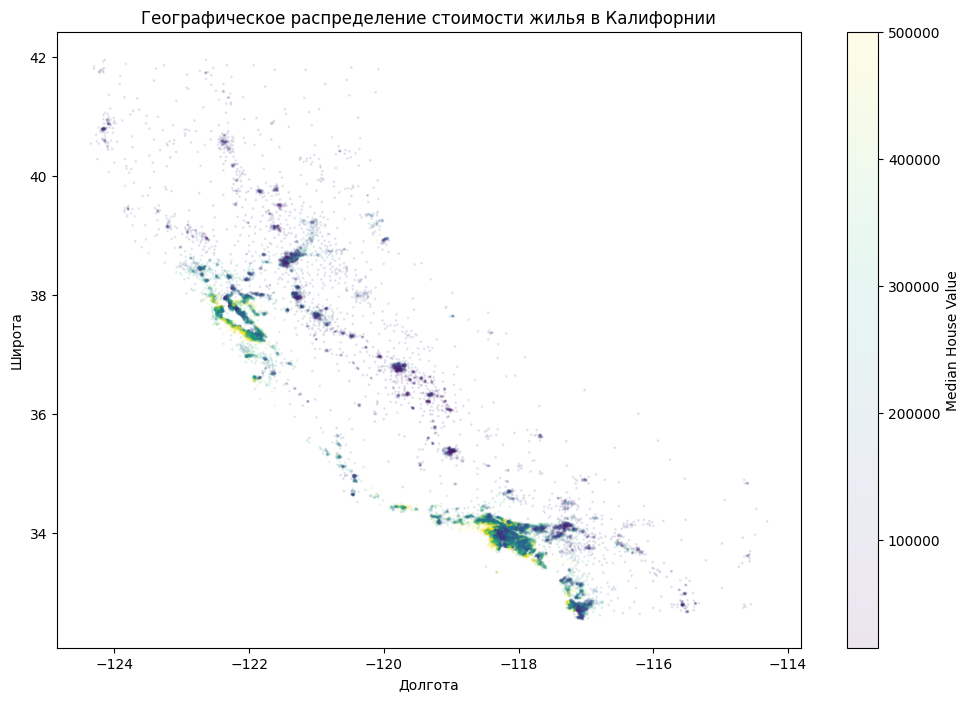

In [ ]:
# Строю scatterplot
plt.figure(figsize=(12, 8))
sc = plt.scatter(
    df["longitude"],
    df["latitude"],
    c=df["median_house_value"],  # цвет в зависимости от стоимости
    alpha=0.1,  # прозрачность для видимости плотности
    cmap="viridis",  # цветовая карта
    s=1,  # маленький размер точек
)

# Добавляю цветовую шкалу
cbar = plt.colorbar(sc)
cbar.set_label("Median House Value")

# добавляю подписи осей и заголовок
plt.xlabel("Долгота")
plt.ylabel("Широта")
plt.title("Географическое распределение стоимости жилья в Калифорнии")
plt.show()

# Задание №7. Корреляционная матрица
Постройте матрицу корреляций (heatmap) для всех числовых признаков.
- С каким признаком сильнее всего коррелирует стоимость жилья (median_house_value)?
- Есть ли признаки, которые очень сильно коррелируют между собой (мультиколлинеарность)?

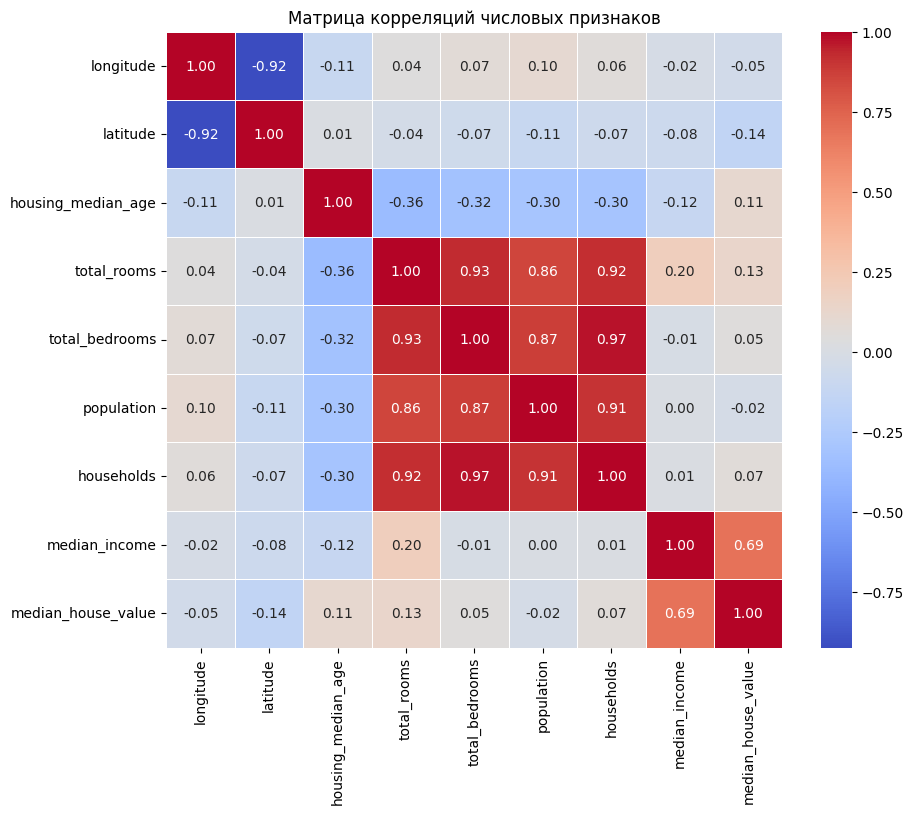

In [ ]:
# для начала выделю только числовые признаки (иск. ocean_proximity)
heatmap_df = df.select_dtypes(include=["float64", "int64"])

#  вычисляю матрицу корреляций
corr_matrix = heatmap_df.corr()

# строю heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True, linewidths=0.5
)
plt.title("Матрица корреляций числовых признаков")
plt.show()

Напишите ответы на вопросы здесь в виде пунктов:
1. Стоимость жилья сильнее всего коррелирует с доходом (median_house_value/median_income)
2. Мультиколлиниарность наблюдается для признаков: total_rooms и total_bedrooms – корреляция около 0.93;
total_rooms и households – корреляция около 0.92; total_bedrooms и households

# Задание №8. Связь дохода и стоимости
Постройте точечный график (scatter plot), где по оси X — median_income, а по оси Y — median_house_value. 
- Опишите характер зависимости (линейная, нелинейная, есть ли "потолок").

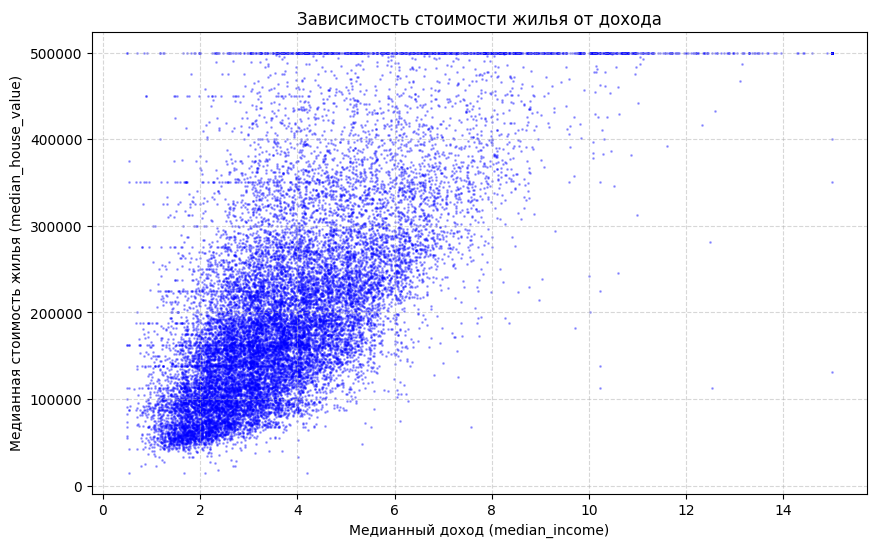

In [ ]:
# Scatterplot
plt.figure(figsize=(10, 6))
plt.scatter(df["median_income"], df["median_house_value"], alpha=0.3, s=1, c="blue")
plt.xlabel("Медианный доход (median_income)")
plt.ylabel("Медианная стоимость жилья (median_house_value)")
plt.title("Зависимость стоимости жилья от дохода")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

Напишите ответы на вопросы здесь в виде пунктов:
1.  Наблюдается положительная корреляция — с ростом медианного дохода стоимость жилья в среднем увеличивается.
Выраженная линейная зависимость - до уровня 6(x). Далее - разброс увеличивается. "Потолок" значений - на уровне 500000, что соответствует ранее проведенному анализу. 

# Задание №9. Анализ стоимости по категориям
Используя boxplot (ящик с усами), визуализируйте распределение стоимости жилья (median_house_value) в зависимости от близости к океану (ocean_proximity).
- Где жилье в среднем дороже: на островах (ISLAND) или в заливе (NEAR BAY)?

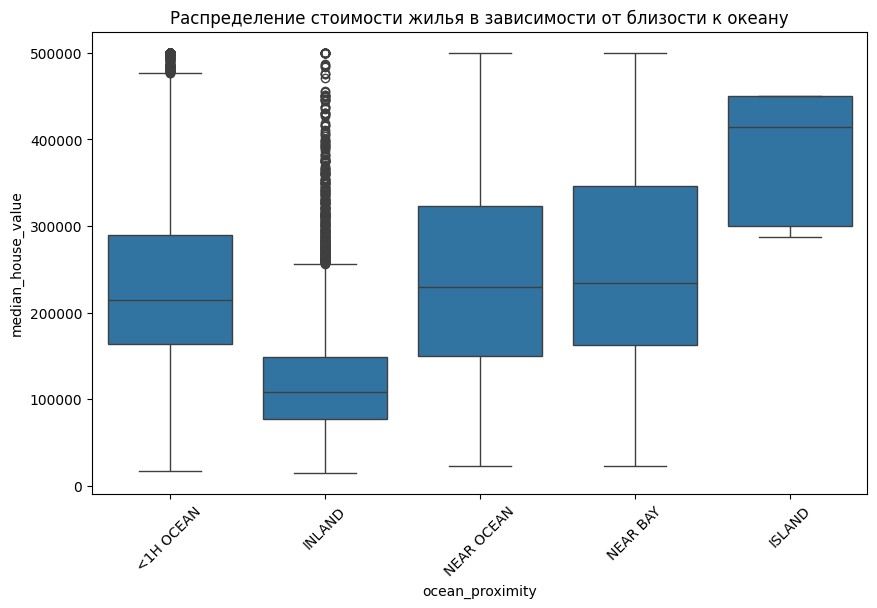

In [ ]:
# строю boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(
    x="ocean_proximity",
    y="median_house_value",
    data=df,
    order=["<1H OCEAN", "INLAND", "NEAR OCEAN", "NEAR BAY", "ISLAND"],
)
plt.title("Распределение стоимости жилья в зависимости от близости к океану")
plt.xticks(rotation=45)
plt.show()

Напишите ответы на вопросы здесь в виде пунктов:
1.  В среднем жильё на островах (ISLAND) дороже, чем в заливе (NEAR BAY). Это подтверждается визуальным сравнением положения медиан (линий внутри ящиков) и общим уровнем значений.

# Задание №10. Масштабирование признаков
В датасете признаки total_rooms, total_bedrooms и population даны для всего района, а не для одного дома. Это может сбивать с толку (большой район — много комнат).
Создайте два новых признака:
- rooms_per_household = общее кол-во комнат / кол-во домохозяйств.
- population_per_household = население / кол-во домохозяйств.


Посмотрите .describe() для новых признаков. Есть ли аномалии (например, 1000 человек в одном доме)?

In [ ]:
# создаю новые признаки:
df["rooms_per_household"] = df["total_rooms"] / df["households"]
df["population_per_household"] = df["population"] / df["households"]

df[["rooms_per_household", "population_per_household"]].describe()

,rooms_per_household,population_per_household
count,20640.000000,20640.000000
mean,5.429000,3.070655
std,2.474173,10.386050
min,0.846154,0.692308
25%,4.440716,2.429741
50%,5.229129,2.818116
75%,6.052381,3.282261
max,141.909091,1243.333333


Напишите ответы на вопросы здесь в виде пунктов:
1. Среднее значение 3.07 человека на домохозяйство, медиана 2.81
Максимум составляет 1243 человека на одно домохозяйство - что является аномалией. 

# Задание №11*. Какие еще визуализации можно построить основываясь на предыдущих шагах и на более обширном анализе данных по-вашему мнению?

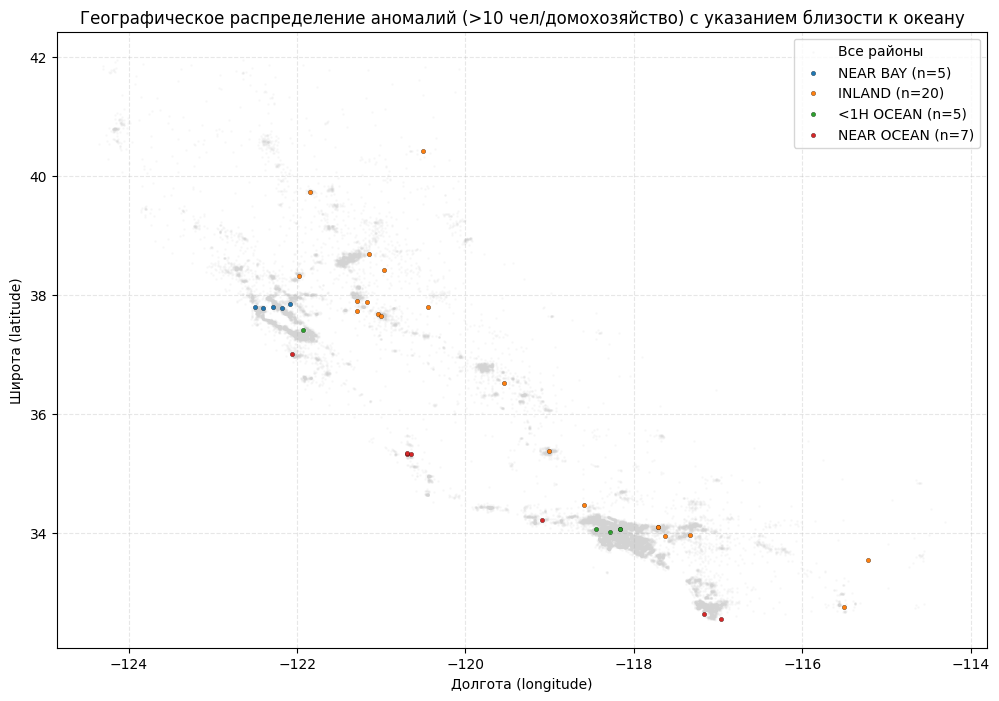

In [ ]:
# ДОПОЛНИТЕЛЬНЫЕ ВИЗУАЛИЗАЦИИ (1):

# Географическое распределение выбросов (аномальных значений) в зависимости от района

# Определяю как аномалию, если кол-во человек на домохозяйство > 1
anomalies = df[df["population_per_household"] > 10].copy()

# выделяю уникальные категории среди аномалий
categories = anomalies["ocean_proximity"].unique()

# задаю цвета
colors = plt.cm.tab10(range(len(categories)))
color_dict = dict(zip(categories, colors))

plt.figure(figsize=(12, 8))

# Фоновые точки – все районы (полупрозрачные серые)
plt.scatter(
    df["longitude"], df["latitude"], alpha=0.1, c="lightgrey", s=1, label="Все районы"
)

# раскрашиваю аномалии в зависимости от расположения
for cat in categories:
    cat_data = anomalies[anomalies["ocean_proximity"] == cat]
    plt.scatter(
        cat_data["longitude"],
        cat_data["latitude"],
        c=[color_dict[cat]],
        s=10,
        label=f"{cat} (n={len(cat_data)})",
        edgecolors="black",
        linewidth=0.2,
    )

# подписываю оси и заголовки
plt.xlabel("Долгота (longitude)")
plt.ylabel("Широта (latitude)")
plt.title(
    "Географическое распределение аномалий (>10 чел/домохозяйство) с указанием близости к океану"
)

# легенда и сетки
plt.legend()
plt.grid(True, linestyle="--", alpha=0.3)

plt.show()

<Axes: >

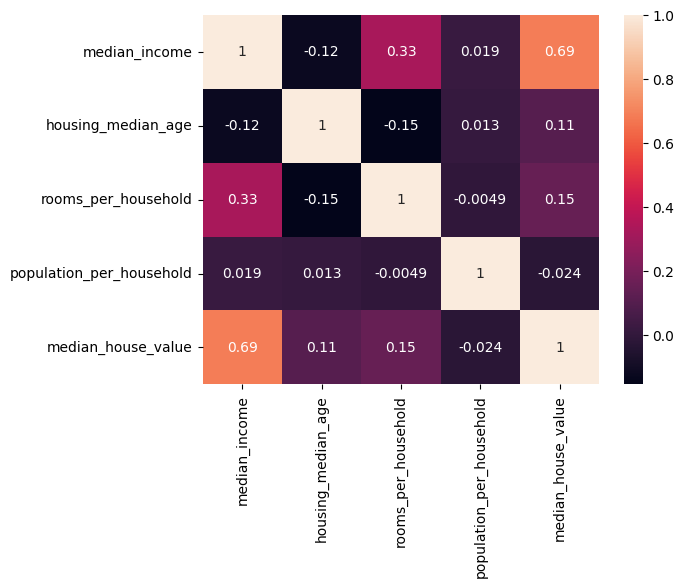

In [74]:
# ДОПОЛНИТЕЛЬНЫЕ ВИЗУАЛИЗАЦИИ (2):

# Матрица корреляций с новыми признаками (rooms_per_household и population_per_household)
# Для чего: оценить, насколько эти новые признаки коррелируют с целевой переменной и между собой, и не добавляют ли они мультиколлинеарность.

sns.heatmap(
    df[
        [
            "median_income",
            "housing_median_age",
            "rooms_per_household",
            "population_per_household",
            "median_house_value",
        ]
    ].corr(),
    annot=True,
)

# Вывод: rooms_per_household (0.14) и population_per_household (-0.02) показывают очень слабую связь с ценой.
# То есть сами по себе признаки количество комнат или людей на домохозяйство не являются хорошими предикторами стоимости.